In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from scipy.stats import chi2_contingency

In [2]:
df = sns.load_dataset("titanic")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("DATASET OVERVIEW")
print("=" * 50)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Number of Rows: 891
Number of Columns: 15

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [5]:
print("MISSING VALUES")
print("=" * 50)

print(df.isnull().sum())

MISSING VALUES
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
survival_counts = df["survived"].value_counts()

print("SURVIVAL COUNTS")
print("=" * 50)
print(survival_counts)

print("\nSURVIVAL RATE:")
print(round(df["survived"].mean() * 100, 2), "%")

SURVIVAL COUNTS
0    549
1    342
Name: survived, dtype: int64

SURVIVAL RATE:
38.38 %


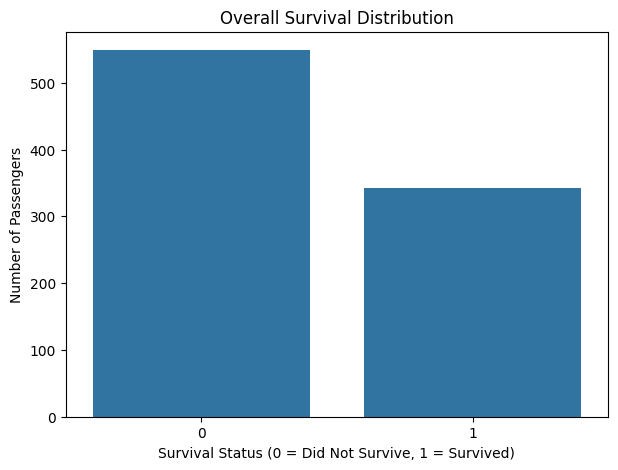

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="survived"
)

plt.title("Overall Survival Distribution")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.savefig("week5_overall_survival.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
gender_class_survival = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("SURVIVAL RATE BY GENDER AND CLASS")
print("=" * 50)
print(gender_class_survival)

SURVIVAL RATE BY GENDER AND CLASS
sex     pclass
female  1         96.81
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64


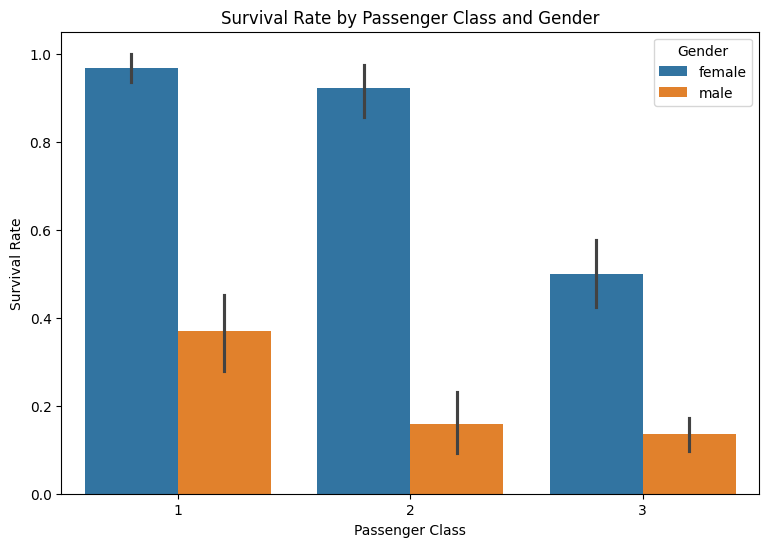

In [11]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Gender")

plt.savefig(
    "week5_gender_class_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
contingency_table = pd.crosstab(
    df["sex"],
    df["survived"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

n = contingency_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency_table.shape[0] - 1,
                    contingency_table.shape[1] - 1))
)

print("STATISTICAL ANALYSIS")
print("=" * 50)

print("Chi-Square Statistic:", round(chi2, 4))
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Cramer's V:", round(cramers_v, 4))

STATISTICAL ANALYSIS
Chi-Square Statistic: 260.717
P-value: 1.1973570627755645e-58
Degrees of Freedom: 1
Cramer's V: 0.5409


In [15]:
# Select features and target

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

print("Features selected:")
print(features)

print("\nTarget variable:")
print("survived")

Features selected:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target variable:
survived


In [16]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Model training completed successfully.")

Model training completed successfully.


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

FINAL MODEL PERFORMANCE
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
ROC-AUC  : 0.8436


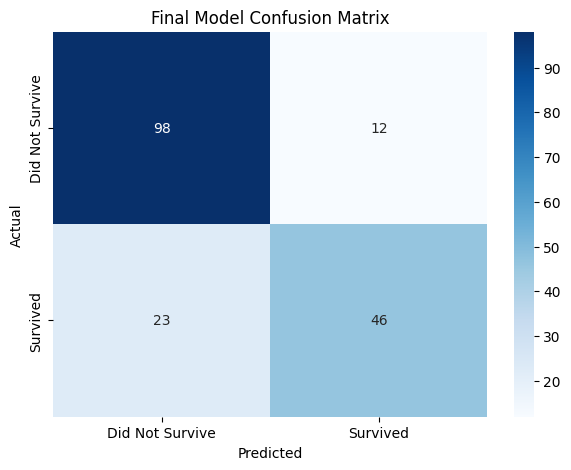

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "week5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

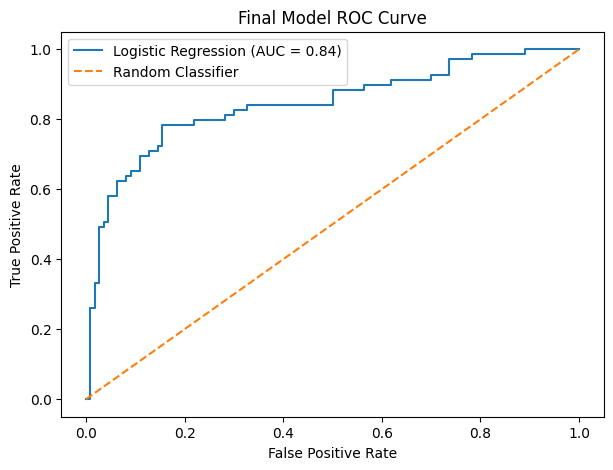

In [19]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Final Model ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(
    "week5_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()